In [160]:
import pypsa
import pandas as pd

# Load the pre-optimization network
network = pypsa.Network("../tyndp2024_network_2030_preoptimization.nc")
print(f"Loaded network: {len(network.buses)} buses, {len(network.generators)} generators")

# Add one slack generator per bus
# Slack has unlimited capacity but very high marginal cost
# so the solver only uses it when no real generation/import can cover the load
SLACK_COST = 3_000

added = 0
for bus in network.buses.index:
    name = f"{bus}-slack"
    if name not in network.generators.index:
        network.add(
            "Generator",
            name,
            bus=bus,
            carrier="slack",
            p_nom=1e9,           # effectively unlimited
            p_nom_extendable=False,
            marginal_cost=SLACK_COST,
            p_min_pu=0.0,
            p_max_pu=1.0,
        )
        added += 1

print(f"Added {added} slack generators (one per bus)")
print(f"Total generators now: {len(network.generators)}")

out_path = "../tyndp2024_network_2030_with_slack.nc"
network.export_to_netcdf(out_path)
print(f"\nSaved → {out_path}")


INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'TYNDP2024_Electricity_2030' has buses, carriers, generators, links, loads, storage_units


Loaded network: 55 buses, 504 generators


Added 55 slack generators (one per bus)
Total generators now: 559


INFO:pypsa.network.io:Exported network 'TYNDP2024_Electricity_2030' saved to '../tyndp2024_network_2030_with_slack.nc contains: storage_units, carriers, generators, links, buses, loads



Saved → ../tyndp2024_network_2030_with_slack.nc


In [ ]:
# import time

# print("Running full-year optimization (8760 h) with Gurobi + slack generators...")
# start = time.time()

# status, condition = network.optimize(
#     solver_name="gurobi",
#     io_api="direct",
#     solver_options={"threads": 8},
# )

# elapsed = time.time() - start
# print(f"Status    : {status}  |  Condition: {condition}")
# print(f"Time      : {elapsed/60:.1f} min")


Index(['AL00-slack', 'AT00-slack', 'BA00-slack', 'BE00-slack', 'BG00-slack',
       'CH00-slack', 'CY00-slack', 'CZ00-slack', 'DE00-slack', 'DKE1-slack',
       'DKW1-slack', 'EE00-slack', 'ES00-slack', 'FI00-slack', 'FR00-slack',
       'FR15-slack', 'GB00-slack', 'GBNI-slack', 'GR00-slack', 'GR03-slack',
       'HR00-slack', 'HU00-slack', 'IE00-slack', 'ITCA-slack', 'ITCN-slack',
       'ITCS-slack', 'ITN1-slack', 'ITS1-slack', 'ITSA-slack', 'ITSI-slack',
       'LT00-slack', 'LUB1-slack', 'LUF1-slack', 'LUG1-slack', 'LUV1-slack',
       'LV00-slack', 'ME00-slack', 'MK00-slack', 'MT00-slack', 'NL00-slack',
       'NOM1-slack', 'NON1-slack', 'NOS0-slack', 'PL00-slack', 'PT00-slack',
       'RO00-slack', 'RS00-slack', 'SE01-slack', 'SE02-slack', 'SE03-slack',
       'SE04-slack', 'SI00-slack', 'SK00-slack', 'ITCO-slack', 'ITVI-slack'],
      dtype='object', name='name')


Running full-year optimization (8760 h) with Gurobi + slack generators...


INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - threads: 8


Set parameter Username


INFO:gurobipy:Set parameter Username


...

INFO:gurobipy:Presolve removed 18257172 rows and 1692255 columns (presolve time = 30s)...


Presolve removed 18257437 rows and 1711180 columns (presolve time = 35s)...


INFO:gurobipy:Presolve removed 18257437 rows and 1711180 columns (presolve time = 35s)...


Presolve removed 18257438 rows and 1711262 columns (presolve time = 41s)...


INFO:gurobipy:Presolve removed 18257438 rows and 1711262 columns (presolve time = 41s)...


In [ ]:
# Save the optimized network (includes all dispatch results: generators_t.p, storage_units_t, etc.)
out_path = "../tyndp2024_network_2030_slack_optimized.nc"
network.export_to_netcdf(out_path)
print(f"Saved optimized network → {out_path}")


In [161]:
network = pypsa.Network("../solved_networks/tyndp2024_network_2030_slack_optimized_26.nc")
print(f"Loaded optimized network: {len(network.buses)} buses, {len(network.generators)} generators")


INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'TYNDP2024_Electricity_2030' has buses, carriers, generators, links, loads, storage_units, sub_networks


Loaded optimized network: 55 buses, 559 generators


In [163]:
import pandas as pd

# Slack dispatch results
slack_p = network.generators_t.p.filter(like="-slack")   # MW per hour per bus

# Total annual load served (MWh) — sum across all buses and all hours
total_load_mwh = network.loads_t.p_set.sum().sum()

# Hours where at least one slack was active
active_mask   = (slack_p > 0.1).any(axis=1)
active_hours  = slack_p[active_mask]

total_slack_mwh  = slack_p.sum().sum()
pct_of_load      = 100.0 * total_slack_mwh / total_load_mwh

print("=" * 60)
print("SLACK COVERAGE SUMMARY")
print("=" * 60)
print(f"  Total annual load          : {total_load_mwh/1e6:>10.3f} TWh")
print(f"  Total energy covered by slack: {total_slack_mwh:>10.1f} MWh")
print(f"  Slack share of total load  : {pct_of_load:>10.4f} %")
print(f"  Hours where slack was active: {len(active_hours):>9} / {len(network.snapshots)}")
print()

if len(active_hours) == 0:
    print("Slack never activated — network is fully feasible!")
else:
    # Per-bus breakdown 
    slack_per_bus = slack_per_bus[slack_per_bus > 0.1]
    slack_per_bus.index = slack_per_bus.index.str.replace("-slack", "")

    # Load per bus for percentage calculation
    load_per_bus = network.loads_t.p_set.sum()
    load_per_bus.index = load_per_bus.index.str.replace(" load", "")

    print(f"{'BUS':<8} {'Slack [MWh]':>14} {'Bus load [MWh]':>16} {'Coverage [%]':>14}")
    print("-" * 56)
    for bus, mwh in slack_per_bus.items():
        # match load column — loads are usually named "<BUS> load" or just the bus
        bus_load = 0.0
        for col in network.loads_t.p_set.columns:
            if network.loads.loc[col, "bus"] == bus:
                bus_load += network.loads_t.p_set[col].sum()
        pct = 100.0 * mwh / bus_load if bus_load > 0 else float("nan")
        print(f"  {bus:<6} {mwh:>14.1f} {bus_load:>16.1f} {pct:>13.4f}%")

    # Top 10 worst hours
    print("\nTop 10 hours with highest slack dispatch:")
    print(f"  {'Timestamp':<25} {'Total MW':>10}  Active buses")
    print("  " + "-" * 70)
    top_hours = slack_p.sum(axis=1).sort_values(ascending=False).head(10)
    for ts, mw in top_hours.items():
        buses_active = slack_p.loc[ts][slack_p.loc[ts] > 0.1]
        buses_str = ", ".join(
            f"{b.replace('-slack', '')}={v:.1f}MW" for b, v in buses_active.items()
        )
        # What % of that hour's total load was covered by slack?
        hour_load = network.loads_t.p_set.loc[ts].sum()
        hour_pct  = 100.0 * mw / hour_load
        print(f"  {str(ts):<25} {mw:>8.1f} MW  ({hour_pct:.3f}% of load)  [{buses_str}]")


SLACK COVERAGE SUMMARY
  Total annual load          :   3947.469 TWh
  Total energy covered by slack:    98860.6 MWh
  Slack share of total load  :     0.0025 %
  Hours where slack was active:       249 / 8760

BUS         Slack [MWh]   Bus load [MWh]   Coverage [%]
--------------------------------------------------------
  DE00          83582.5      715914135.9        0.0117%
  FR15           8689.1        2670503.0        0.3254%
  LUG1           5015.7        8944031.7        0.0561%
  MT00             34.2        3806391.2        0.0009%

Top 10 hours with highest slack dispatch:
  Timestamp                   Total MW  Active buses
  ----------------------------------------------------------------------
  2030-12-19 16:00:00        21123.3 MW  (3.000% of load)  [DE00=20414.7MW, FR15=21.6MW, LUG1=687.0MW]
  2030-12-19 15:00:00        19829.0 MW  (2.911% of load)  [DE00=19326.9MW, LUG1=502.1MW]
  2030-12-19 17:00:00        18697.6 MW  (2.619% of load)  [DE00=17855.6MW, FR15=70.1MW, L

Slack used: 85.1 GWh  (0.011% of total dispatch)
=== DE00 — Annual generation by carrier (2030) ===
  Carrier                        TWh   Share %
  ──────────────────────────────────────────────
  onwind                       219.4     29.6%
  offwind                      128.5     17.3%
  solar-pv-rooftop             104.7     14.1%
  solar-pv-utility              85.0     11.5%
  gas                           57.2      7.7%
  other-res                     48.7      6.6%
  dsr                           42.3      5.7%
  hydro-ror                     16.8      2.3%
  hydro-phs-pure                16.0      2.2%
  other-thermal                 14.4      1.9%
  hydro-phs                      5.0      0.7%
  battery                        2.6      0.4%
  h2-ccgt                        0.7      0.1%
  hydro-reservoir                0.6      0.1%
  ⚠ slack (deficit)              0.1      0.0%
  oil-light                      0.0      0.0%
  ──────────────────────────────────────────────
  T

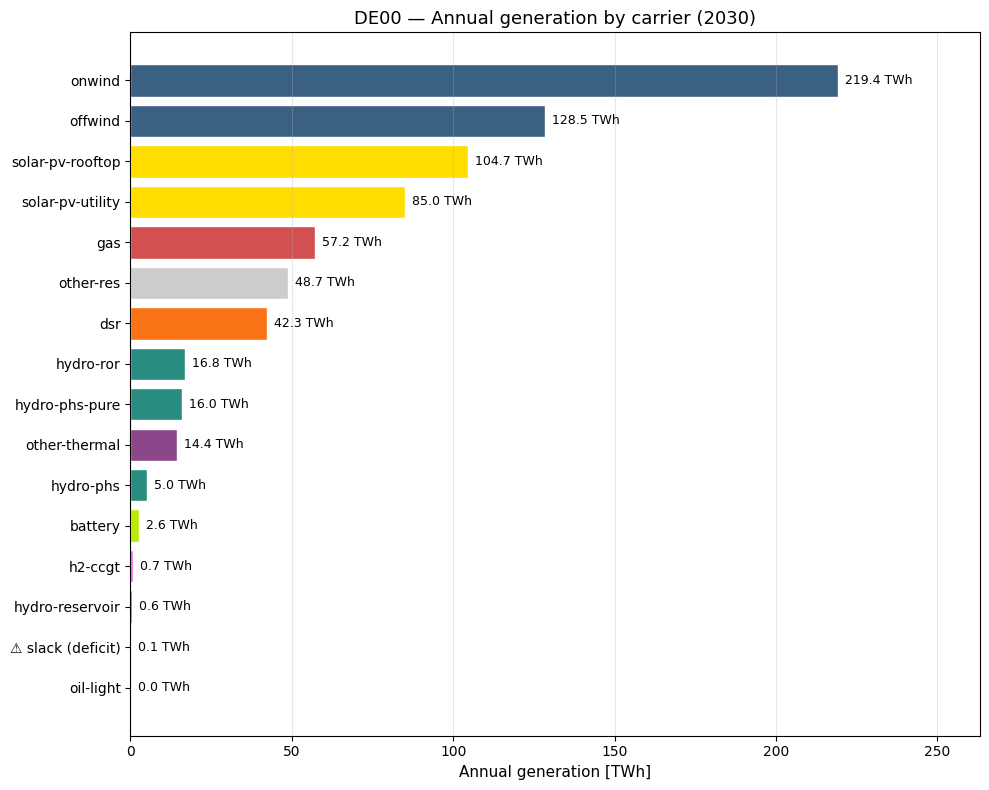

In [164]:
import matplotlib.pyplot as plt

bus = "DE00"

# ── Annual generation per carrier (generators, excluding slack) ───────────────
de_gens = network.generators[
    (network.generators.bus == bus) & (network.generators.carrier != "slack")
].index
gen_annual = (
    network.generators_t.p[de_gens]
    .sum()
    .groupby(network.generators.loc[de_gens, "carrier"])
    .sum()
    / 1e6  # → TWh
)

# ── Annual storage discharge (positive only) ─────────────────────────────────
de_stor = network.storage_units[network.storage_units.bus == bus].index
if len(de_stor) > 0 and len(network.storage_units_t.p.columns) > 0:
    stor_annual = (
        network.storage_units_t.p[de_stor].clip(lower=0)
        .sum()
        .groupby(network.storage_units.loc[de_stor, "carrier"])
        .sum()
        / 1e6
    )
    gen_annual = pd.concat([gen_annual, stor_annual])

# ── Add slack separately (so it always shows even if small) ──────────────────
slack_col = f"{bus}-slack"
if slack_col in network.generators_t.p.columns:
    slack_twh = network.generators_t.p[slack_col].sum() / 1e6
    if slack_twh > 0:
        gen_annual["⚠ slack (deficit)"] = slack_twh
        print(f"Slack used: {slack_twh*1000:.1f} GWh  ({slack_twh/gen_annual.sum()*100:.3f}% of total dispatch)")
    else:
        print("✓ Slack column exists but was never dispatched")
else:
    print(f"⚠ No slack column '{slack_col}' found in generators_t.p")
    print(f"  Available slack columns: {[c for c in network.generators_t.p.columns if 'slack' in c][:5]}")

gen_annual = gen_annual[gen_annual > 0.001].sort_values(ascending=False)

# ── Text output ───────────────────────────────────────────────────────────────
print(f"=== {bus} — Annual generation by carrier (2030) ===")
print(f"  {'Carrier':<25} {'TWh':>8}  {'Share %':>8}")
print("  " + "─" * 46)
total_twh = gen_annual.sum()
for carrier, twh in gen_annual.items():
    share = 100 * twh / total_twh if total_twh > 0 else 0
    print(f"  {carrier:<25} {twh:>8.1f}  {share:>7.1f}%")
print("  " + "─" * 46)
print(f"  {'TOTAL':<25} {total_twh:>8.1f}  {'100.0%':>8}")
print()

gen_annual = gen_annual.sort_values(ascending=True)

# ── Colors from network.carriers (defined during network construction) ────────
colors = [
    network.carriers.loc[c, "color"]
    if c in network.carriers.index and network.carriers.loc[c, "color"]
    else ("#ff0000" if "slack" in c else "#aaaaaa")
    for c in gen_annual.index
]

fig, ax = plt.subplots(figsize=(10, max(5, len(gen_annual) * 0.5)))
bars = ax.barh(gen_annual.index, gen_annual.values, color=colors, edgecolor="white")

for bar, val in zip(bars, gen_annual.values):
    ax.text(bar.get_width() + gen_annual.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.1f} TWh", va="center", fontsize=9)

ax.set_xlabel("Annual generation [TWh]", fontsize=11)
ax.set_title(f"{bus} — Annual generation by carrier (2030)", fontsize=13)
ax.grid(axis="x", alpha=0.3)
ax.set_xlim(0, gen_annual.max() * 1.2)
plt.tight_layout()
plt.show()


=== Marginal price — DE00 (2030) ===
  Annual average :    61.74 €/MWh
  Annual minimum :     0.01 €/MWh  (2030-03-31 10:00:00)
  Annual maximum :  3000.00 €/MWh  (2030-12-19 07:00:00)

Month   Avg €/MWh  Min €/MWh  Max €/MWh
----------------------------------------
  Jan       86.76       5.00     564.00
  Feb       79.34       1.43     183.51
  Mar       62.18       0.01     150.00
  Apr       54.00       0.01      84.86
  May       34.80       0.01      79.85
  Jun       42.91       0.01      82.32
  Jul       41.79       0.01      82.32
  Aug       54.28       0.01      82.32
  Sep       52.79       0.01      84.86
  Oct       65.40       1.24     126.72
  Nov       51.87       1.43     115.00
  Dec      114.98       1.43    3000.00


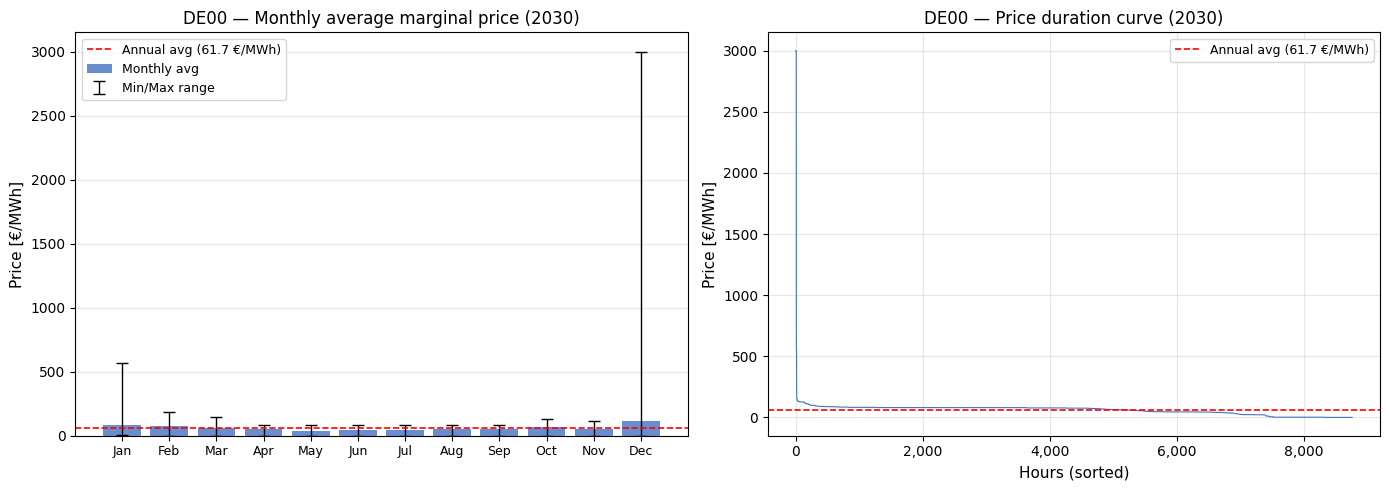

In [165]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

bus = "DE00"

# Marginal price time series for this bus 
# buses_t.marginal_price contains the dual variable (shadow price) of the
# nodal balance constraint — i.e. the system marginal price in €/MWh
if bus not in network.buses_t.marginal_price.columns:
    print(f"⚠ No marginal price data for {bus}. Make sure the network was optimised with Gurobi (dual values required).")
else:
    price = network.buses_t.marginal_price[bus]  # hourly €/MWh series

    annual_avg = price.mean()
    annual_min = price.min()
    annual_max = price.max()

    print(f"=== Marginal price — {bus} (2030) ===")
    print(f"  Annual average : {annual_avg:>8.2f} €/MWh")
    print(f"  Annual minimum : {annual_min:>8.2f} €/MWh  ({price.idxmin()})")
    print(f"  Annual maximum : {annual_max:>8.2f} €/MWh  ({price.idxmax()})")
    print()

    # Monthly averages 
    monthly = price.resample("ME").agg(["mean", "min", "max"])
    monthly.index = monthly.index.strftime("%b")

    print(f"{'Month':<6} {'Avg €/MWh':>10} {'Min €/MWh':>10} {'Max €/MWh':>10}")
    print("-" * 40)
    for month, row in monthly.iterrows():
        print(f"  {month:<4} {row['mean']:>10.2f} {row['min']:>10.2f} {row['max']:>10.2f}")

    # Plot: monthly average price
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: monthly avg/min/max bar + error bars
    ax1 = axes[0]
    x = range(len(monthly))
    bars = ax1.bar(x, monthly["mean"], color="#4472c4", alpha=0.8, label="Monthly avg")
    ax1.errorbar(x, monthly["mean"],
                 yerr=[monthly["mean"] - monthly["min"], monthly["max"] - monthly["mean"]],
                 fmt="none", color="black", capsize=4, linewidth=1, label="Min/Max range")
    ax1.axhline(annual_avg, color="red", linestyle="--", linewidth=1.2, label=f"Annual avg ({annual_avg:.1f} €/MWh)")
    ax1.set_xticks(list(x))
    ax1.set_xticklabels(monthly.index, fontsize=9)
    ax1.set_ylabel("Price [€/MWh]", fontsize=11)
    ax1.set_title(f"{bus} — Monthly average marginal price (2030)", fontsize=12)
    ax1.legend(fontsize=9)
    ax1.grid(axis="y", alpha=0.3)

    # Right: hourly price duration curve (sorted descending)
    ax2 = axes[1]
    sorted_price = price.sort_values(ascending=False).values
    ax2.plot(sorted_price, color="#4472c4", linewidth=0.8)
    ax2.axhline(annual_avg, color="red", linestyle="--", linewidth=1.2, label=f"Annual avg ({annual_avg:.1f} €/MWh)")
    ax2.set_xlabel("Hours (sorted)", fontsize=11)
    ax2.set_ylabel("Price [€/MWh]", fontsize=11)
    ax2.set_title(f"{bus} — Price duration curve (2030)", fontsize=12)
    ax2.legend(fontsize=9)
    ax2.grid(alpha=0.3)
    ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))

    plt.tight_layout()
    plt.show()


In [ ]:
## DE
## wind: 209,4 + 124,1 = 333,5 TWh; 240 + 131 = 371
## solar: 104,7 + 82,4 = 187,1 TWh; = 191
## other-thermal: 13,9 TWh; 1 TWh 
## other RES: 114,5 TWh; 70 TWh
## hydro-ror: 16,8 TWh; 17
## gas: 52,3 TWh; 60 TWh

## battery: 2,8 TWh; 2,48 TWh
## DSR: 0,0 TWh; 44,5 TWh
## phs-pure: 17,6 TWh; 16,15 TWh
## phs: 5,7 TWh; 2,67 TWh

## total-my:    333,5 + 187,1 + 13,9 + 114,5  + 16,8  + 52,3  + 2,8   + 0     + 17,6    + 5,7 = 744,2 TWh
## total-tyndp: 371   + 191   + 1    + 70     + 17    + 60    + 2,48  + 44,5  + 16,15   + 2,67 = 775 TWh



Month   Model Avg   Market    Difference    Difference in %
-----------------------------------------------------------
Jan      86.76       84.6     +1.85         +2.19%
Feb      79.34       81.8     -2.28         -2.79%
Mar      62.18       67.5     -6.50         -9.63%
Apr      54.00       60.3     -8.19         -13.58%
May      34.80       55.7     -25.95        -46.57%
Jun      42.91       57.6     -20.40        -35.42%
Jul      41.79       62.6     -25.93        -41.42%
Aug      54.28       65.2     -17.35        -26.61%
Sep      52.79       70.5     -19.25        -27.30%
Oct      65.40       70.3     -6.32         -8.99%
Nov      51.87       80.1     -29.45        -36.77%
Dec      114.98       77.7     +36.97       +47.57%



Month   Model Avg   Market
--------------------------
Jan      79.18       84.6 
Feb      73.95       81.8 
Mar      59.12       67.5 
Apr      51.49       60.3 
May      27.15       55.7 
Jun      34.00       57.6 
Jul      32.99       62.6 
Aug      43.48       65.2 
Sep      48.14       70.5 
Oct      63.15       70.3 
Nov      48.43       80.1 
Dec      104.48       77.7 


Month   Avg €/MWh  Min €/MWh  Max €/MWh
----------------------------------------
  Jan       86.45       5.00     515.46
  Feb       79.52       1.43     200.00
  Mar       61.00       0.01     152.42
  Apr       52.11       0.01      84.86
  May       29.75       0.01      79.85
  Jun       37.20       0.01      79.85
  Jul       36.67       0.01      82.32
  Aug       47.85       0.01      82.32
  Sep       51.25       0.01      82.32
  Oct       63.98       1.24     126.72
  Nov       50.65       1.43     125.38
  Dec      114.67       1.43    3000.00

  Month   Avg €/MWh  Min €/MWh  Max €/MWh
----------------------------------------
  Jan       86.76       5.00     564.00
  Feb       79.34       1.43     183.51
  Mar       62.18       0.01     150.00
  Apr       54.00       0.01      84.86
  May       34.80       0.01      79.85
  Jun       42.91       0.01      82.32
  Jul       41.79       0.01      82.32
  Aug       54.28       0.01      82.32
  Sep       52.79       0.01      84.86
  Oct       65.40       1.24     126.72
  Nov       51.87       1.43     115.00
  Dec      114.98       1.43    3000.00

In [ ]:
Month   Avg €/MWh  Min €/MWh  Max €/MWh
----------------------------------------
  Jan      105.01       1.43    3000.00
  Feb       78.93       1.43    3000.00
  Mar       60.04       0.01    3000.00
  Apr       43.96       0.01      79.85
  May       20.18       0.01      79.85
  Jun       27.72       0.01      79.85
  Jul       26.18       0.01      79.85
  Aug       32.69       0.01      79.85
  Sep       39.36       0.01      79.85
  Oct       60.73       0.02     129.26
  Nov       45.11       1.43     126.72
  Dec      146.34       1.43    3000.00

In [149]:

# Annual generation by carrier for every bus — saves plots to bus_annual_generation_plots/

import os
import matplotlib.pyplot as plt
import pandas as pd

OUTPUT_DIR = "../bus_annual_generation_plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)

all_buses = sorted(network.buses.index)
print(f"Generating plots for {len(all_buses)} buses -> {OUTPUT_DIR}/")

for bus in all_buses:
    # Generators (excluding slack)
    bus_gens = network.generators[
        (network.generators.bus == bus) &
        (network.generators.carrier != "slack")
    ].index

    gen_annual = pd.Series(dtype=float)
    if len(bus_gens) > 0:
        gen_annual = (
            network.generators_t.p[bus_gens]
            .sum()
            .groupby(network.generators.loc[bus_gens, "carrier"])
            .sum()
            / 1e6  # TWh
        )

    # Storage discharge (positive = generation)
    bus_stor = network.storage_units[network.storage_units.bus == bus].index
    if len(bus_stor) > 0 and len(network.storage_units_t.p.columns) > 0:
        avail_stor = [s for s in bus_stor if s in network.storage_units_t.p.columns]
        if avail_stor:
            stor_annual = (
                network.storage_units_t.p[avail_stor].clip(lower=0)
                .sum()
                .groupby(network.storage_units.loc[avail_stor, "carrier"])
                .sum()
                / 1e6
            )
            gen_annual = pd.concat([gen_annual, stor_annual])

    # Slack — show in red if ever dispatched
    slack_col = f"{bus}-slack"
    if slack_col in network.generators_t.p.columns:
        slack_twh = network.generators_t.p[slack_col].sum() / 1e6
        if slack_twh > 1e-4:
            gen_annual["⚠ slack (deficit)"] = slack_twh

    gen_annual = gen_annual[gen_annual > 0.001].sort_values(ascending=True)

    if len(gen_annual) == 0:
        print(f"  {bus}: no generation — skipping")
        continue

    total_twh = gen_annual.sum()

    # Colors from network.carriers
    colors = [
        network.carriers.loc[c, "color"]
        if c in network.carriers.index and network.carriers.loc[c, "color"]
        else ("#ff0000" if "slack" in c else "#aaaaaa")
        for c in gen_annual.index
    ]

    fig, ax = plt.subplots(figsize=(10, max(4, len(gen_annual) * 0.45)))
    bars = ax.barh(gen_annual.index, gen_annual.values, color=colors, edgecolor="white")

    for bar, val in zip(bars, gen_annual.values):
        share = 100 * val / total_twh if total_twh > 0 else 0
        ax.text(
            bar.get_width() + gen_annual.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.1f} TWh  ({share:.1f}%)",
            va="center", fontsize=8,
        )

    ax.set_xlabel("Annual generation [TWh]", fontsize=11)
    ax.set_title(f"{bus} — Annual generation by carrier (2030)\nTotal: {total_twh:.1f} TWh", fontsize=12)
    ax.grid(axis="x", alpha=0.3)
    ax.set_xlim(0, gen_annual.max() * 1.25)

    plt.tight_layout()
    out_file = os.path.join(OUTPUT_DIR, f"{bus}_annual_generation.png")
    plt.savefig(out_file, dpi=150, bbox_inches="tight")
    plt.close(fig)

print(f"\nDone. Saved plots for {len(all_buses)} buses to: {OUTPUT_DIR}/")


Generating plots for 55 buses -> ../bus_annual_generation_plots/
  ITCO: no generation — skipping
  ITCO: no generation — skipping
  ITVI: no generation — skipping
  LUB1: no generation — skipping
  LUF1: no generation — skipping
  ITVI: no generation — skipping
  LUB1: no generation — skipping
  LUF1: no generation — skipping

Done. Saved plots for 55 buses to: ../bus_annual_generation_plots/

Done. Saved plots for 55 buses to: ../bus_annual_generation_plots/
